Simple climate model to assess effects of metamorphic $\mathrm{SO}_2$ and $\mathrm{CO}_2$ fluxes
==

This code creates a simple model, based largely on $\textit{Smith et al. (2021), Journal of Geophysical Research: Atmospheres}$, and references therein, to explore the climate effects of computed $\mathrm{SO_2}$ and $\mathrm{CO_2}$ from metamorphism, like that during the End-Triassic period. A traditional perspective would discount the potential climatic influence of the sulfur fluxes, as they would occur in the troposphere (where removal is rapid) instead of being injected into the stratosphere (where removal is slow). However, a sustained flux of sulfur into the troposphere could cause cooling effects similar to those produced from anthropogenic pollution. Here, our aim is to assess whether climate-relevant impacts from metamorphism-driven sulfur releases are plausible.

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [2]:
#Set climate model emulaters to use
models = ['CanESM5', 
          'E3SM-1-0', 
          'GFDL-CM4', 
          'GFDL-ESM4', #s_SO2 outlier
          'GISS-E2-1-G', #alpha_SO2 outlier
          'HadGEM3-GC31-LL', 
          'IPSL-CM6A-LR', #Default
          'MIROC6', 
          'MRI-ESM2-0', #s_SO2 outlier
          'NorESM2-LM', #s_SO2 outlier
          'UKESM1-0-LL'] #Climate models used in Smith et al. (2021), JGRA, doi:10.1029/2020JD033622

In [3]:
#Set metamorphic S and C emission models
t_ = 'Instantaneous' #10yr or Instantaneous (default)
mS = 'HF' #Sulfur options: AR, eqm, Fegley, HF (default), Linert, LR; HF_volceq
mC = 'AR' #Carbon options: AR (default), eqm, LR, Ro; AR_volceq
defaults = (t_ == 'Instantaneous') & (mS == 'HF') & (mC == 'AR') #Check if all defaults are set (produce figures if True)

Emissions of $\mathrm{SO}_2$ and $\mathrm{CO_2}$
=

This section loads in the emissions data for metamorphic outgassing events for sulfur (assuming 0th, 1st, and 2nd order kinetics) and $\mathrm{CO}_2$

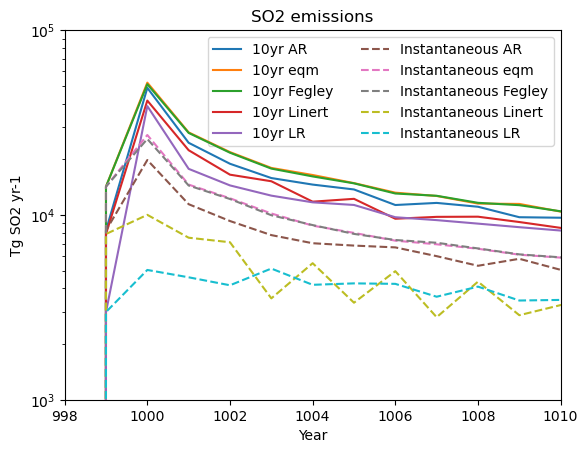

In [4]:
#Check all SO2 emissions options
for tt_, ls in zip(['10yr','Instantaneous'],['solid','dashed']):
    for mS_ in ['AR', 'eqm', 'Fegley', 'Linert', 'LR']:
        filename_S = f'{tt_}_Sflux_{mS_}.csv'
        E_SO2 = np.array(pd.read_csv(filename_S,header=None)).flatten() * (32+2*16)/32 * 1e-9 #Tg SO2 yr-1
        plt.plot(E_SO2,label=f'{tt_} {mS_}',zorder=10,ls=ls)
plt.legend(ncol=2)
plt.yscale('log')
plt.ylim(1e3,1e5)
plt.xlim(998,1010)
plt.title('SO2 emissions')
plt.ylabel('Tg SO2 yr-1')
plt.xlabel('Year')
plt.show()

In [5]:
#SO2 emissions file in kg S yr-1
filename_S = f'{t_}_Sflux_{mS}.csv'
E_SO2 = np.array(pd.read_csv(filename_S,header=None)).flatten() * (32+2*16)/32 * 1e-9 #Tg SO2 yr-1

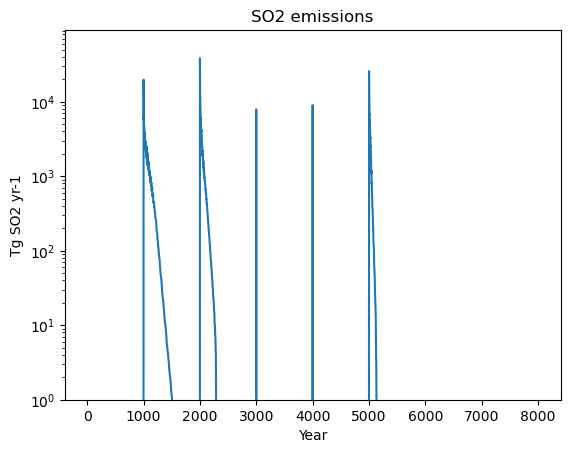

In [6]:
#Check SO2 emissions
plt.plot(E_SO2,label='',zorder=10)
plt.yscale('log')
plt.ylim(1)
plt.title('SO2 emissions')
plt.ylabel('Tg SO2 yr-1')
plt.xlabel('Year')
plt.show()

In [7]:
#CO2 emissions in kg yr-1
filename_C = f'{t_}_Cflux_{mC}.csv'
E_CO2 = np.array(pd.read_csv(filename_C,header=None)).flatten() * (12+2*16)/12 * 1e-9 #Tg CO2 yr-1

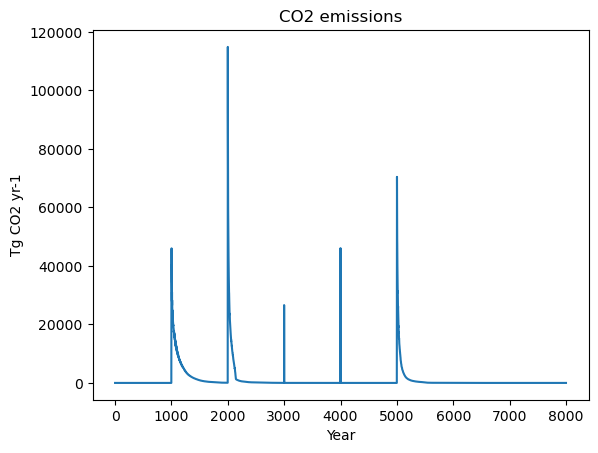

In [8]:
#Check CO2 emissions
plt.plot(E_CO2)
plt.title('CO2 emissions')
plt.ylabel('Tg CO2 yr-1')
plt.xlabel('Year')
plt.show()

For later calculations, it will be more convenient to express the $\mathrm{CO}_2$ flux as a partial pressure.

In [9]:
E_pCO2 = (E_CO2*1e9)/(4*np.pi*(6.3781*1e6)**2)*9.8*10 #µatm

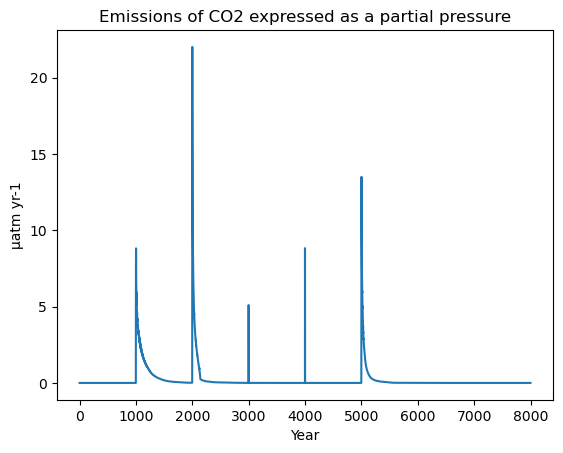

In [10]:
#Check CO2 emissions as partial pressures
plt.plot(E_pCO2)
plt.title('Emissions of CO2 expressed as a partial pressure')
plt.ylabel('µatm yr-1')
plt.xlabel('Year')
plt.show()

Aerosol direct effect
=

The aerosol direct radiative effect refers to how scattering (reflection) and absorption of light by aerosol particles influences Earth's energy budget. Following Smith et al. (2021), we parameterize the effective radiative forcing due to aerosol-radiation interactions (direct effect plus changes in clouds caused by related changes in atmospheric temperature profiles) as: 

$\mathrm{ERF_{ARI}} = \alpha_\mathrm{{SO}_2}E_\mathrm{{SO}_2}$


In this work, we neglect any contributions from carbonaceous aerosols, which we would expect to be negligible from the metamorphic source.

In [11]:
alpha_SO2 = {#Values from Smith et al. (2021), JGRA, Table 3, based on fits to climate model data
    'CanESM5'         : -2.5,
    'E3SM-1-0'        : -0.9,
    'GFDL-CM4'        : -2.6,
    'GFDL-ESM4'       : -2.6,
    'GISS-E2-1-G'     : -6.7,
    'HadGEM3-GC31-LL' : -2.9,
    'IPSL-CM6A-LR'    : -0.7, #Default
    'MIROC6'          : -1.8,
    'MRI-ESM2-0'      : -3.2,
    'NorESM2-LM'      : -1.5,
    'UKESM1-0-LL'     : -2.4,
    'MMM'             : -2.5 #Multi-model mean (MMM)
} #mW m-2 (Tg yr-1)-1

In [12]:
def ERFari(model='IPSL-CM6A-LR'):
    """
    Smith et al. (2021), JGRA, Eq. 1
    
    Parameters
    ----------
    model : str
    Name of individual model or MMM for multi-model mean
    
    Returns
    -------
    ERFari : array
    Direct aerosol forcing values in W m-2
    """
    
    ERFari = alpha_SO2[model]*E_SO2/1000
    
    return ERFari #W m-2

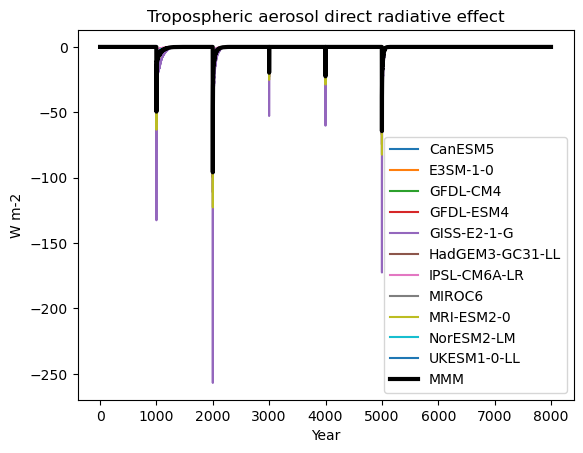

In [13]:
#Full view
for model in models:
    plt.plot(ERFari(model),label=model)
plt.plot(ERFari('MMM'),label='MMM',c='k',lw=3)
plt.legend()
plt.title('Tropospheric aerosol direct radiative effect')
plt.ylabel('W m-2')
plt.xlabel('Year')
plt.show()

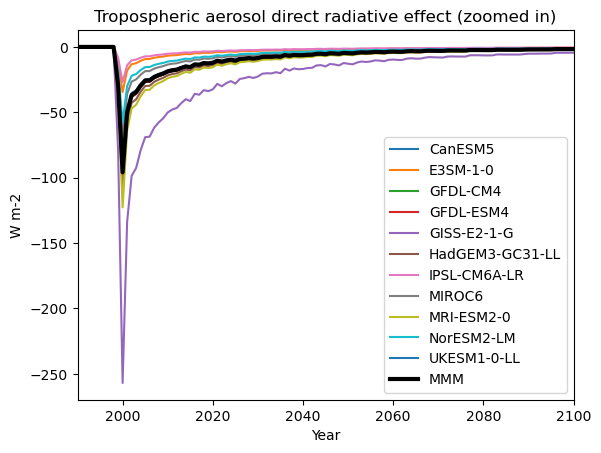

In [14]:
#Zoom in
for model in models:
    plt.plot(ERFari(model),label=model)
plt.plot(ERFari('MMM'),label='MMM',c='k',lw=3)
plt.legend()
plt.title('Tropospheric aerosol direct radiative effect (zoomed in)')
plt.ylabel('W m-2')
plt.xlabel('Year')
plt.xlim(1990,2100)
plt.show()

Aerosol indirect effects
=

The aerosol indirect radiative effect refers to changes in clouds caused by the role of aerosol particles in nucleating cloud droplets influences Earth's energy budget. For the same volume of liquid water in a cloud, spreading the water over a larger number of small droplets maximizes the effective surface area (Twomey effect). The total volume of liquid can also change due to cloud adjustments to the Twomey effect, such as a reduction in precipitation (extra cooling) or an increase in evaporation (offsetting warming). Following Smith et al. (2021), we parameterize the effective radiative forcing due to aerosol-cloud interactions (Twomey effect plus adjustments) as: 

$\mathrm{ERF_{ACI}} = -\beta$ $\mathrm{ln}(1+\frac{E_\mathrm{{SO}_2}}{s_\mathrm{{SO}_2}})$


In [15]:
beta = {#Values from Smith et al. (2021), JGRA, Table 3, based on fits to climate model data
    'CanESM5'         : 0.727,
    'E3SM-1-0'        : 2.048,
    'GFDL-CM4'        : 3.501,
    'GFDL-ESM4'       : 3096,
    'GISS-E2-1-G'     : 0.563,
    'HadGEM3-GC31-LL' : 1.004,
    'IPSL-CM6A-LR'    : 1.097, #Default
    'MIROC6'          : 0.773,
    'MRI-ESM2-0'      : 7.404,
    'NorESM2-LM'      : 13502,
    'UKESM1-0-LL'     : 0.741,
    'MMM'             : 1.223
} #W m-2

s_SO2 = {#Values from Smith et al. (2021), JGRA, Table 3, based on fits to climate model data
    'CanESM5'         : 58.9,
    'E3SM-1-0'        : 155.9,
    'GFDL-CM4'        : 692.7,
    'GFDL-ESM4'       : 913500, 
    'GISS-E2-1-G'     : 117.9,
    'HadGEM3-GC31-LL' : 95.4,
    'IPSL-CM6A-LR'    : 358.3, #Default
    'MIROC6'          : 117.2,
    'MRI-ESM2-0'      : 1276,
    'NorESM2-LM'      : 1915000, #Larger values for shape parameter imply more linear forcing with emissions
    'UKESM1-0-LL'     : 39.5, #Smaller values for shape parameter imply more logarithmic forcing with emissions
    'MMM'             : 156.5
} #TgSO2 yr-1

In [16]:
def ERFaci(model='IPSL-CM6A-LR'):
    """
    Smith et al. (2021), JGRA, Eq. 2
    
    Parameters
    ----------
    model : str
    Name of individual model or MMM for multi-model mean
    
    Returns
    -------
    ERFaci : array
    Indirect aerosol forcing values in W m-2
    """
    
    ERFaci = -beta[model]*np.log(1+E_SO2/s_SO2[model])
    
    return ERFaci #W m-2

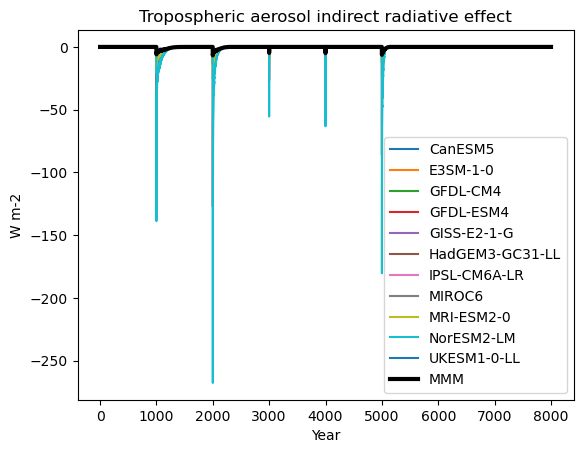

In [17]:
#Full view
for model in models:
    plt.plot(ERFaci(model),label=model)
plt.plot(ERFaci('MMM'),label='MMM',c='k',lw=3)
plt.legend()
plt.title('Tropospheric aerosol indirect radiative effect')
plt.ylabel('W m-2')
plt.xlabel('Year')
plt.show()

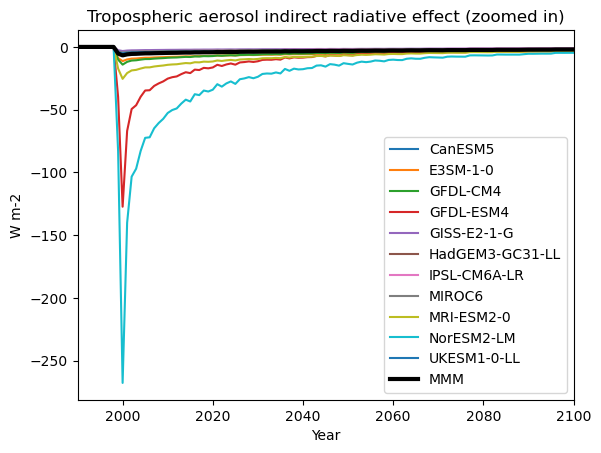

In [18]:
#Zoom-in
for model in models:
    plt.plot(ERFaci(model),label=model)
plt.plot(ERFaci('MMM'),label='MMM',c='k',lw=3)
plt.legend()
plt.title('Tropospheric aerosol indirect radiative effect (zoomed in)')
plt.ylabel('W m-2')
plt.xlabel('Year')
plt.xlim(1990,2100)

plt.show()

Greenhouse gas forcing
=

$\mathrm{CO_2}$ is long-lived in the atmosphere; it is only fully removed by geological sequestration over many thousands of years. It does enter the shallow ocean on annual timescales, however, and then the deep ocean over centuries. We treat the Earth system as being comprised of three "boxes": an atmosphere, a mixed-layer ocean (in contact with the atmosphere), and a deep ocean.

$\textbf{Atmosphere}$: $\mathrm{CO_2}$ is added to the atmosphere through emissions from the metamorphic source and removed through a sink via the surface ocean. We do not consider the terrestrial carbon cycle here. The rate of exchange of $\mathrm{CO_2}$ between the atmosphere and ocean is governed by a transfer coefficient (Tr) that is the product of a gas transfer velocity ($\kappa$) related to wind speed, temperature, and salinity and the solubility of $\mathrm{CO_2}$ in seawater ($\alpha$). From $\textit{Takahashi et al. (2009), Deep-Sea Research II}$, Figure 12, we take a representative Tr value of 0.05 $\mathrm{yr}^{-1}$.

$\frac{dp_\mathrm{CO_2}^{\mathrm{atm}}}{dt} = E_\mathrm{CO_2} - \kappa \alpha (p_\mathrm{CO_2}^{\mathrm{atm}}-p_\mathrm{CO_2}^{\mathrm{mix}}) $


$\textbf{Mixed-layer ocean}$: $\mathrm{CO_2}$ is added to the mixed-layer ocean through exchange with the atmosphere, as above, and removed via mixing with the deep ocean. For the latter, we define a mixing parameter $\zeta$, the inverse of which gives the characteristic ocean overturning timescale.

$\frac{dp_\mathrm{CO_2}^{\mathrm{mix}}}{dt} = \kappa \alpha (p_\mathrm{CO_2}^{\mathrm{atm}}-p_\mathrm{CO_2}^{\mathrm{mix}}) - \zeta (p_\mathrm{CO_2}^{\mathrm{mix}}-p_\mathrm{CO_2}^{\mathrm{deep}})$

$\textbf{Deep ocean}$: $\mathrm{CO_2}$ is added to the deep ocean through mixing with the mixed-layer ocean, as above. Ultimately, carbon will be removed through sedimentation and burial, but this process is negligibly slow given an analysis period of only a few millennia.

$\frac{dp_\mathrm{CO_2}^{\mathrm{deep}}}{dt} = \zeta (p_\mathrm{CO_2}^{\mathrm{mix}}-p_\mathrm{CO_2}^{\mathrm{deep}})$

As our initial condition, we assume all of the carbon reservoirs are in equilibrium with an atmospheric concentration of 1500 ppm by volume, based on data from $\textit{Foster et al. (2017), Nature Communications}$.

In [19]:
#Set integration parameters
dt = 1 #yr
Tr = 0.05 #yr-1
zeta = 1/250 #yr-1
pCO2_0 = 1500*(44/29) #µatm

#Initial values: Equilibrated with atmosphere at 1500 ppmv
pCO2_atm = [pCO2_0] #µatm
pCO2_mix = [pCO2_0] #µatm
pCO2_deep = [pCO2_0] #µatm

#Integrate
for i in range(1,len(E_CO2)): #Euler method
    dpCO2_atm = (E_pCO2[i-1]-Tr*(pCO2_atm[i-1]-pCO2_mix[i-1]))*dt
    dpCO2_mix = (Tr*(pCO2_atm[i-1]-pCO2_mix[i-1])-zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
    dpCO2_deep = (zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
        
    pCO2_atm.append(pCO2_atm[i-1]+dpCO2_atm)
    pCO2_mix.append(pCO2_mix[i-1]+dpCO2_mix)
    pCO2_deep.append(pCO2_deep[i-1]+dpCO2_deep)

#Store values
pCO2_atm = np.array(pCO2_atm)
pCO2_mix = np.array(pCO2_mix)
pCO2_deep = np.array(pCO2_deep)

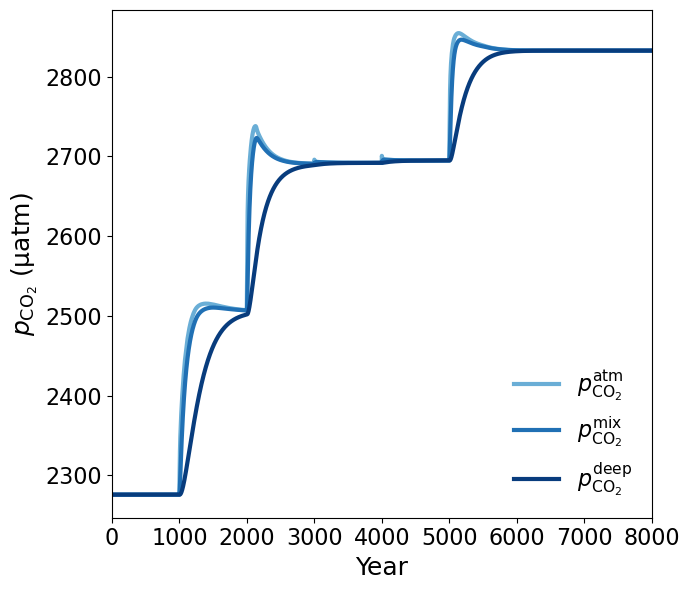

In [20]:
#
###Figure 6: CO2 concentrations
#

plt.figure(figsize=(7,6))
plt.clf()
fs = 18

plt.plot(pCO2_atm,label=r'$p_\mathrm{CO_2}^\mathrm{atm}$',c=cm.Blues(.5),lw=3)
plt.plot(pCO2_mix,label=r'$p_\mathrm{CO_2}^\mathrm{mix}$',c=cm.Blues(.75),lw=3)
plt.plot(pCO2_deep,label=r'$p_\mathrm{CO_2}^\mathrm{deep}$',c=cm.Blues(.95),lw=3)
plt.legend(frameon=False,fontsize=fs-2,loc=4)
plt.ylabel(r'$p_\mathrm{CO_2}$ (µatm)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Year',fontsize=fs)
plt.xticks(fontsize=fs-2)
plt.xlim(0,8000)

plt.tight_layout()

if defaults: plt.savefig(f'Fig6.pdf')

plt.show()

For a generic case, the effective radiative forcing from changes in $\mathrm{CO_2}$ is estimated using the assessed value for a doubling of $\mathrm{CO}_2$ from the IPCC AR6 WG1 report ($\textit{Forster et al., 2021}$):

$\mathrm{ERF_{CO_2}} = \frac{3.93}{\ln 2} \ln (\frac{p_\mathrm{CO_2}^{\mathrm{atm}}}{p_\mathrm{CO_2,0}^{\mathrm{atm}}})$

For each individual model, the effective radiative forcing from changes in $\mathrm{CO_2}$ is estimated using values derived from instantaneous 4x $\mathrm{CO}_2$ experiments ($F_\mathrm{4x}$):

$\mathrm{ERF_{CO_2}} = \frac{F_\mathrm{4x}}{\ln 4} \ln (\frac{p_\mathrm{CO_2}^{\mathrm{atm}}}{p_\mathrm{CO_2,0}^{\mathrm{atm}}})$

In [21]:
F_4x = {#Values from Smith et al. (2021), JGRA, Table S1, based on fits to climate model data
    'CanESM5'         : 7.61,
    'E3SM-1-0'        : 7.42,
    'GFDL-CM4'        : 8.45,
    'GFDL-ESM4'       : 7.34, 
    'GISS-E2-1-G'     : 8.11,
    'HadGEM3-GC31-LL' : 7.46,
    'IPSL-CM6A-LR'    : 7.52,
    'MIROC6'          : 7.73,
    'MRI-ESM2-0'      : 8.03,
    'NorESM2-LM'      : 10.21,
    'UKESM1-0-LL'     : 7.61,
} #W m-2

In [22]:
def ERF_CO2(model='IPSL-CM6A-LR'):
    """
    Calculate CO2 effective radiative forcing based on concentration
    
    Parameters
    ----------
    model : str
    Name of individual model or MMM for multi-model mean
    
    Returns
    -------
    ERFco2 : array
    CO2 forcing values in W m-2
    """
    
    if model == 'MMM':
        ERFco2 = 3.93/np.log(2)*np.log(pCO2_atm/pCO2_0)
    else:
        ERFco2 = F_4x[model]/np.log(4)*np.log(pCO2_atm/pCO2_0)
    
    return ERFco2#W m-2

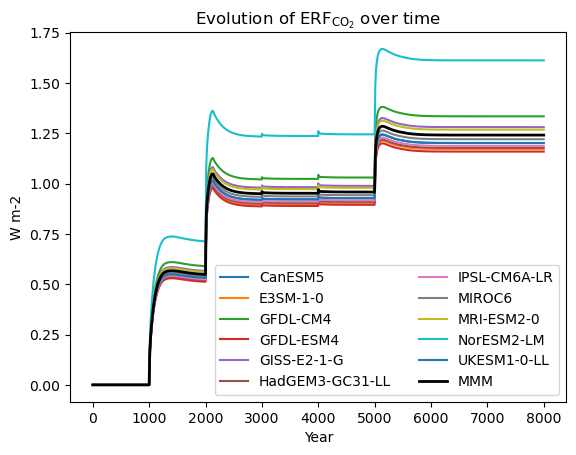

In [23]:
#Check ERF_CO2 values
for model in models:
    plt.plot(ERF_CO2(model),label=model)
plt.plot(ERF_CO2('MMM'),label='MMM',c='k',lw=2)
plt.legend(ncol=2)
plt.title(r'Evolution of $\mathrm{ERF_{CO_2}}$ over time')
plt.ylabel('W m-2')
plt.xlabel('Year')
plt.show()

Temperature changes
==

We use a simple two box model of fast (surface ocean) and slow (deep ocean) temperature responses to a forcing (e.g., $\textit{Held et al. (2010), Journal of Climate}$). $T_\mathrm{mix}$ and $T_\mathrm{deep}$ represent temperature anomalies from an initial equilibrium state. The mixed-layer temperature responds to a top-of-atmosphere (TOA) forcing $F$ (radiative imbalance before any temperature response). As the temperature changes, the TOA imbalance is resolved at a rate given by the climate feedback parameter $\lambda$. There is also heat exchange between the mixed-layer and deep oceans, occurring at a rate given by the product of the efficacy of deep ocean heat uptake $\epsilon$ and a heat transport term $\gamma$. The heat capacities of the mixed-layer and deep ocean are given by $C_\mathrm{mix}$ and $C_\mathrm{deep}$, respectively.

$C_\mathrm{mix} \frac{dT_\mathrm{mix}}{dt} = F + \lambda T_\mathrm{mix} - \epsilon \gamma (T_\mathrm{mix}-T_\mathrm{deep})$

$\epsilon C_\mathrm{deep} \frac{dT_\mathrm{deep}}{dt} = \epsilon \gamma (T_\mathrm{mix}-T_\mathrm{deep})$

In [24]:
#
###Set parameters for temperature tendency equations
#

C_mix = {} #W yr m-2 K-1
C_deep = {} #W yr m-2 K-1
lmda = {} #W m-2 K-1
gmma = {} #W m-2 K-1
epsn = {} #unitless

#Values from Smith et al. (2021), JGRA, Table S1, based on fits to climate model data

model = 'CanESM5'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.66,7.86,78.83,0.54,1.09

model = 'E3SM-1-0'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.64,8.43,43.77,0.36,1.41

model = 'GFDL-CM4'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.89,7.36,96.54,0.58,1.85

model = 'GFDL-ESM4'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -1.27,8.44,129.94,0.60,1.23

model = 'GISS-E2-1-G'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -1.46,6.52,145.03,0.85,1.09

model = 'HadGEM3-GC31-LL'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.62,8.07,78.11,0.51,1.23

model = 'IPSL-CM6A-LR'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.76,8.21,60.03,0.44,1.35

model = 'MIROC6'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -1.36,9.00,182.38,0.64,1.31

model = 'MRI-ESM2-0'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -1.20,7.89,92.84,0.94,1.34

model = 'NorESM2-LM'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -1.77,6.01,115.66,0.90,1.92

model = 'UKESM1-0-LL'
lmda[model], C_mix[model], C_deep[model], gmma[model], epsn[model] = -0.68,7.77,77.15,0.54,1.14

In [25]:
#Set different combinations of forcers to test
forcers = ['ARI','ACI','AER','GHG','ALL','GHG+ACI']

In [26]:
#Store temperature and forcing data
dd = {}
dd['Tmix'] = {forcer : {} for forcer in forcers}
dd['Tdeep'] = {forcer : {} for forcer in forcers}
dd['F'] = {forcer : {} for forcer in forcers}

#Calculate temperature for each model
for model in models:
    for forcer in forcers:

        #Set forcing
        if forcer == 'ACI': F = ERFaci(model)
        elif forcer == 'ARI': F = ERFari(model)
        elif forcer == 'GHG': F = ERF_CO2(model)
        elif forcer == 'ALL': F = ERFaci(model)+ERFari(model)+ERF_CO2(model)
        elif forcer == 'GHG+ACI': F = ERFaci(model)+ERF_CO2(model)
        elif forcer == 'AER': F = ERFaci(model)+ERFari(model)

        #Initialize model
        Tmix = [0] #K
        Tdeep = [0] #K
        dt = 1 #yr

        #Integrate
        for i in range(1,len(E_SO2)): #Euler method
            dTmix = (F[i-1] + lmda[model]*Tmix[i-1] - epsn[model]*gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_mix[model]
            dTdeep = (gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_deep[model]
            Tmix.append(Tmix[i-1]+dTmix)
            Tdeep.append(Tdeep[i-1]+dTdeep)    

        #Store data
        dd['Tmix'][forcer][model] = np.array(Tmix)
        dd['Tdeep'][forcer][model] = np.array(Tdeep)
        dd['F'][forcer][model] = np.array(F)

#Multi-model mean
for forcer in forcers:
    dd['Tmix'][forcer]['MMM'] = 0
    dd['Tdeep'][forcer]['MMM'] = 0
    dd['F'][forcer]['MMM'] = 0

    #Average all models
    for model in models:
        dd['Tmix'][forcer]['MMM'] += dd['Tmix'][forcer][model]/len(models)
        dd['Tdeep'][forcer]['MMM'] += dd['Tdeep'][forcer][model]/len(models)
        dd['F'][forcer]['MMM'] += dd['F'][forcer][model]/len(models)

Below, we can look at the mixed-layer temperature response for each of our forcing agents:

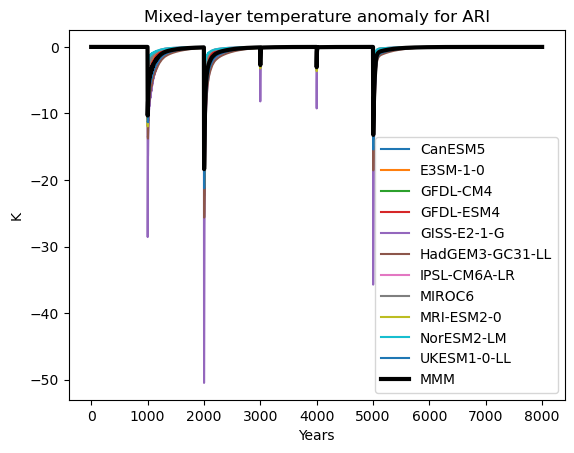

In [27]:
#Direct aerosol effect
forcer = 'ARI'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

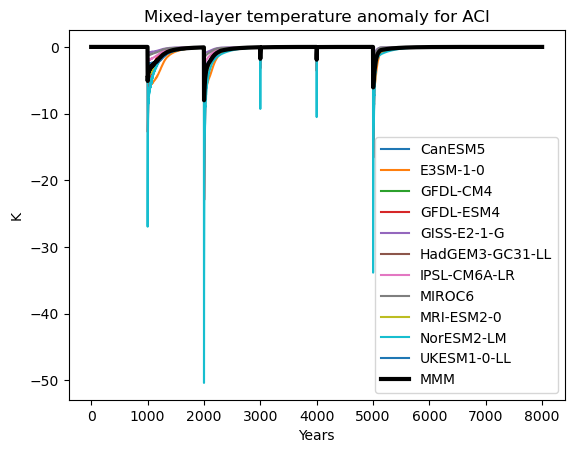

In [28]:
#Indirect aerosol effect
forcer = 'ACI'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

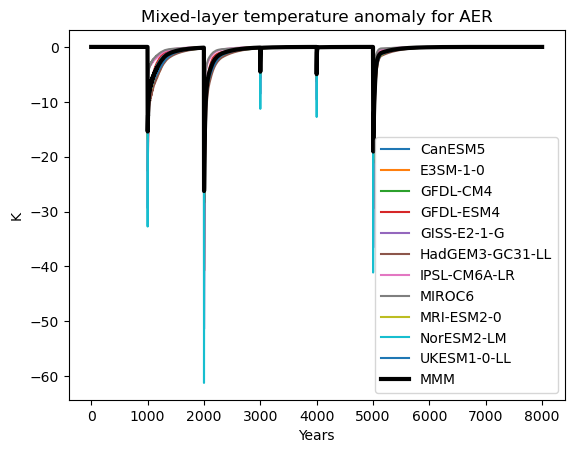

In [29]:
#Total aerosol effect
forcer = 'AER'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

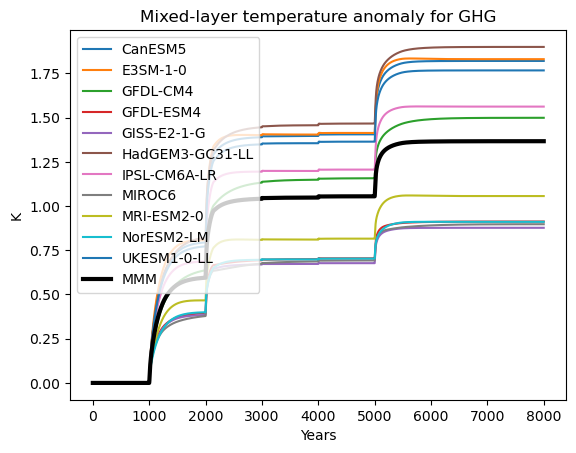

In [30]:
#Greenhouse effect
forcer = 'GHG'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

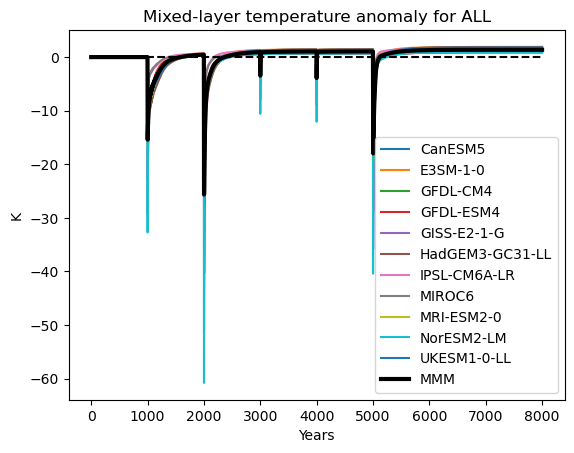

In [31]:
#Combination of all CO2 and aerosol forcings
forcer = 'ALL'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.plot([0,len(E_SO2)],[0,0],'k--')
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

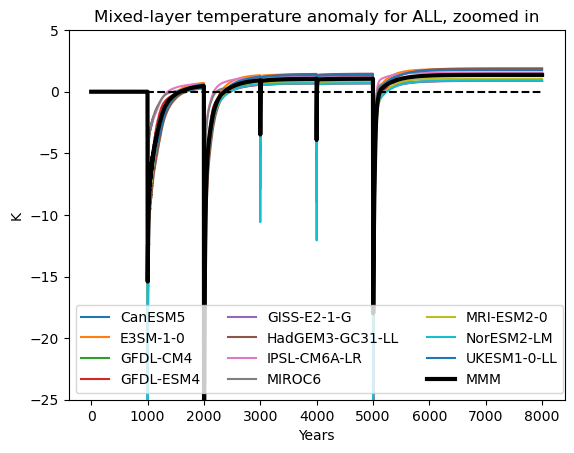

In [32]:
#Combination of all CO2 and aerosol forcings (zoom in)
forcer = 'ALL'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3)
plt.plot([0,len(E_SO2)],[0,0],'k--')
plt.legend(ncol=3)
plt.title('Mixed-layer temperature anomaly for %s, zoomed in' % forcer)
plt.ylabel('K')
plt.xlabel('Years')
plt.ylim(-25,5)
plt.show()

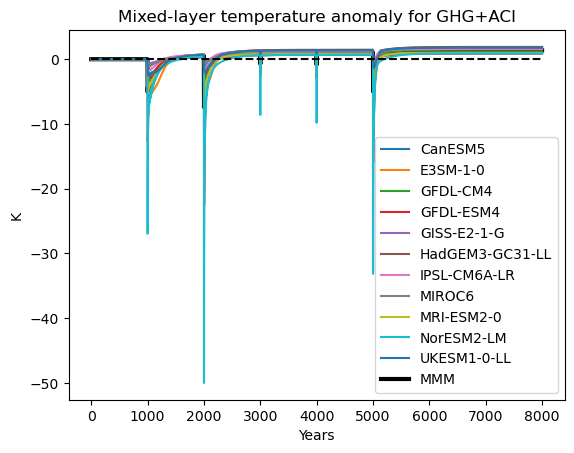

In [33]:
#Combination of CO2 and indirect aerosol forcings
forcer = 'GHG+ACI'
for model in models:
    plt.plot(dd['Tmix'][forcer][model],label=model)
plt.plot(dd['Tmix'][forcer]['MMM'],label='MMM',c='k',lw=3,zorder=0)
plt.plot([0,len(E_SO2)],[0,0],'k--')
plt.legend()
plt.title('Mixed-layer temperature anomaly for %s' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

Conveniently, the total climate response can be linearly decomposed into its aerosol and greenhouse gas components:

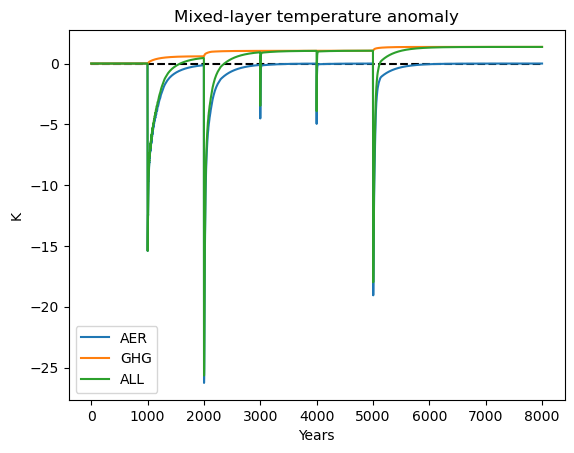

In [34]:
plt.plot(dd['Tmix']['AER']['MMM'],label='AER')
plt.plot(dd['Tmix']['GHG']['MMM'],label=r'GHG')
plt.plot(dd['Tmix']['ALL']['MMM'],label='ALL')
plt.plot([0,len(E_SO2)],[0,0],'k--',zorder=0)
plt.legend()
plt.ylabel('K')
plt.xlabel('Years')
plt.title(f'Mixed-layer temperature anomaly')
plt.show()

Temperature changes are felt throughout the ocean, but the severe aerosol cooling shocks are mostly confined to the mixed-layer.

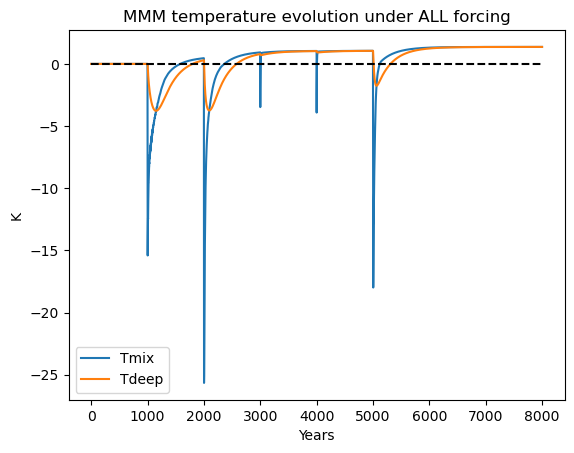

In [35]:
forcer = 'ALL'
plt.plot(dd['Tmix'][forcer]['MMM'],label='Tmix')
plt.plot(dd['Tdeep'][forcer]['MMM'],label='Tdeep')
plt.plot([0,len(E_SO2)],[0,0],'k--')
plt.legend()
plt.title('MMM temperature evolution under %s forcing' % (forcer))
plt.ylabel('K')
plt.xlabel('Years')
plt.show()

Figure 7: Summary plot with IPSL
==

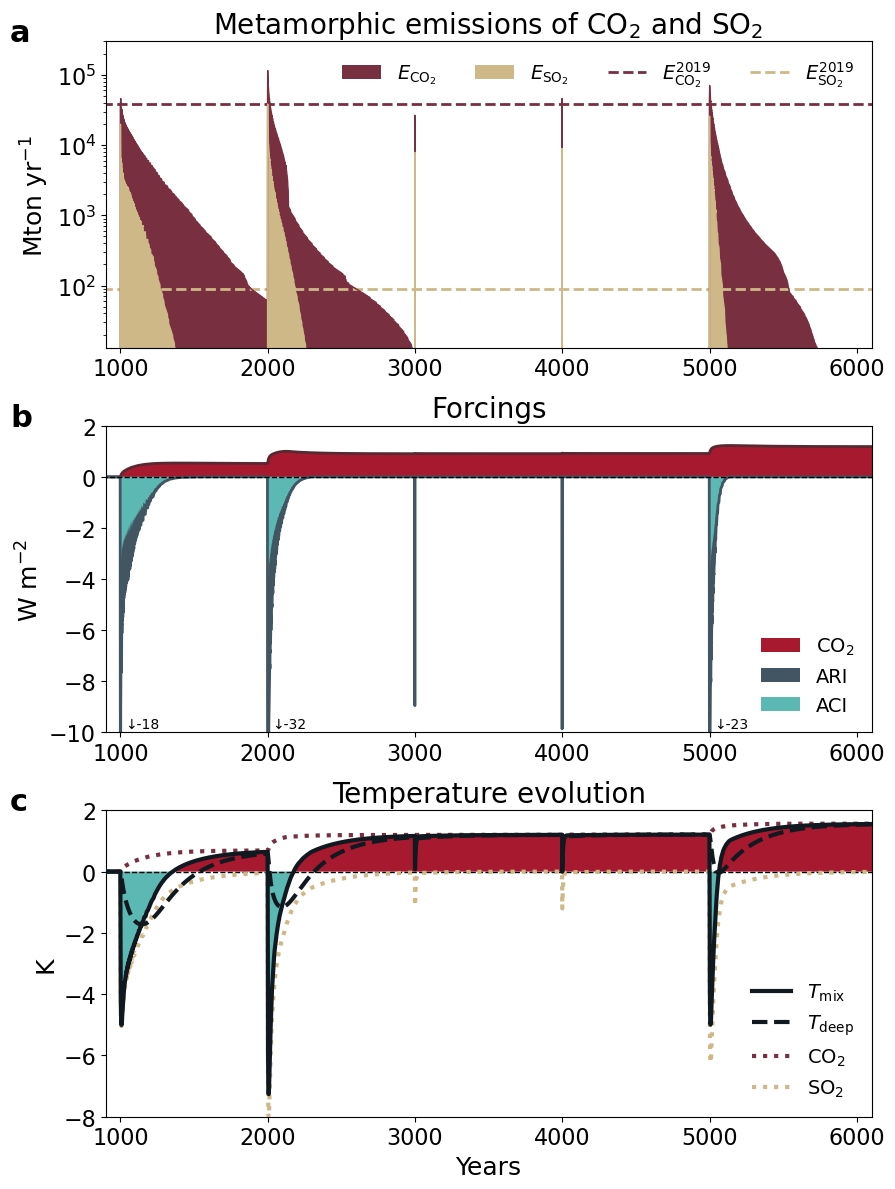

In [36]:
#
###Figure 7: Summary plot
#

plt.figure(figsize=(9,12))
fs = 18

nrow = 3

model = 'IPSL-CM6A-LR'

#Emissions
ax1 = plt.subplot(nrow,1,1)
plt.fill_between(np.arange(len(E_CO2)),0*E_CO2,E_CO2,facecolor='#782F40',label=r'$E_\mathrm{CO_2}$')
plt.fill_between(np.arange(len(E_SO2)),0*E_SO2,E_SO2,facecolor='#CEB888',label=r'$E_\mathrm{SO_2}$')
plt.plot([0,10000],[38.01e3,38.01e3],color='#782F40',lw=2,ls='dashed',label=r'$E_\mathrm{CO_2}^{2019}$')
plt.plot([0,10000],[89.06,89.06],color='#CEB888',lw=2,ls='dashed',label=r'$E_\mathrm{SO_2}^{2019}$')
plt.plot(E_CO2,c='#782F40',lw=1)
plt.plot(E_SO2,c='#CEB888',lw=1)
plt.yscale('log')
plt.xlim(900,6100)
plt.ylim(1.3e1,.3e6)
plt.legend(fontsize=fs-4,frameon=False,loc='upper right',ncol=4)

plt.ylabel(r'$\mathrm{Mton}$ $\mathrm{yr}^{-1}$',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.title(r'Metamorphic emissions of $\mathrm{CO_2}$ and $\mathrm{SO_2}$',fontsize=fs+2)

ax1.text(-.125,1,s='a',transform = ax1.transAxes,fontsize=fs+4,fontweight='bold')

#Forcings
ax2 = plt.subplot(nrow,1,2)
plt.fill_between(np.arange(len(E_SO2)),0*dd['F']['GHG'][model],
                 dd['F']['GHG'][model],facecolor='#A6192E',label=r'$\mathrm{CO}_2$')
plt.fill_between(np.arange(len(E_SO2)),0*dd['F']['AER'][model],
                 dd['F']['AER'][model],facecolor='#425563',label='ARI')
plt.fill_between(np.arange(len(E_SO2)),0*dd['F']['ACI'][model],
                 dd['F']['ACI'][model],facecolor='#5CB8B2',label='ACI')
plt.plot(dd['F']['GHG'][model],c='#572932',lw=2)
plt.plot(dd['F']['AER'][model],c='#425563',lw=2)
plt.plot([0,len(E_SO2)],[0,0],'k--',lw=1)
plt.legend(ncol=1,frameon=False,fontsize=fs-4,loc='lower right')

o1 = np.min(dd['F']['AER'][model][900:1100])
plt.text(1030,-9.4,s=f'\u2193{o1:.0f}',fontsize=fs-8,ha='left',va='top')
o2 = np.min(dd['F']['AER'][model][1900:2100])
plt.text(2030,-9.4,s=f'\u2193{o2:.0f}',fontsize=fs-8,ha='left',va='top')
#o3 = np.min(dd['F']['AER'][model][2900:3100])
#plt.text(3030,-9.5,s=f'\u2193{o3:.0f}',fontsize=fs-8,ha='left',va='top')
#o4 = np.min(dd['F']['AER'][model][3900:4100])
#plt.text(4030,-9.5,s=f'\u2193{o4:.0f}',fontsize=fs-8,ha='left',va='top')
o5 = np.min(dd['F']['AER'][model][4900:5100])
plt.text(5030,-9.4,s=f'\u2193{o5:.0f}',fontsize=fs-8,ha='left',va='top')

plt.ylim(-10,2)
plt.xlim(900,6100)

plt.ylabel(r'$\mathrm{W}$ $\mathrm{m}^{-2}$',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.title(f'Forcings',fontsize=fs+2)

ax2.text(-.125,1,s='b',transform = ax2.transAxes,fontsize=fs+4,fontweight='bold')

#Temperature

ax3 = plt.subplot(nrow,1,3)

plt.plot(dd['Tmix']['ALL'][model],c='#101820',lw=3,ls='solid',zorder=11,label=r'$T_\mathrm{mix}$')
plt.plot(dd['Tdeep']['ALL'][model],c='#101820',lw=3,ls='dashed',zorder=10,label=r'$T_\mathrm{deep}$')
plt.plot(dd['Tmix']['GHG'][model],c='#782F40',lw=3,ls='dotted',zorder=2,label=r'$\mathrm{CO}_2$')
plt.plot(dd['Tmix']['AER'][model],c='#CEB888',lw=3,ls='dotted',zorder=3,label=r'$\mathrm{SO}_2$')
plt.fill_between(np.arange(len(E_CO2)),0*dd['Tmix']['ALL'][model],dd['Tmix']['ALL'][model],
                 where=dd['Tmix']['ALL'][model]>0,facecolor='#A6192E')
plt.fill_between(np.arange(len(E_CO2)),0*dd['Tmix']['ALL'][model],dd['Tmix']['ALL'][model],
                 where=dd['Tmix']['ALL'][model]<0,facecolor='#5CB8B2')
#plt.fill_between(np.arange(len(E_CO2)),0*dd['Tmix']['GHG+ACI'][model],dd['Tmix']['GHG+ACI'][model],
#                 where=dd['Tmix']['GHG+ACI'][model]<0,facecolor='#5CB8B2')

plt.plot([0,len(E_SO2)],[0,0],'k--',lw=1)

plt.legend(ncol=1,frameon=False,fontsize=fs-4,loc='lower right')

plt.ylim(-8,2)
plt.xlim(900,6100)

plt.ylabel('K',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Years',fontsize=fs)
plt.xticks(fontsize=fs-2)
plt.title(f'Temperature evolution',fontsize=fs+2)

ax3.text(-.125,1,s='c',transform = ax3.transAxes,fontsize=fs+4,fontweight='bold')

plt.tight_layout()

if defaults: plt.savefig(f'Fig7.pdf')

plt.show()

Figure 8: Sensitivity to model choice
==

In [37]:
#Short name for each model
short_model = {model : model.split('-')[0] for model in models}
short_model['GFDL-CM4'] = 'GFDL-CM4'
short_model['GFDL-ESM4'] = 'GFDL-ESM4'
short_model

{'CanESM5': 'CanESM5',
 'E3SM-1-0': 'E3SM',
 'GFDL-CM4': 'GFDL-CM4',
 'GFDL-ESM4': 'GFDL-ESM4',
 'GISS-E2-1-G': 'GISS',
 'HadGEM3-GC31-LL': 'HadGEM3',
 'IPSL-CM6A-LR': 'IPSL',
 'MIROC6': 'MIROC6',
 'MRI-ESM2-0': 'MRI',
 'NorESM2-LM': 'NorESM2',
 'UKESM1-0-LL': 'UKESM1'}

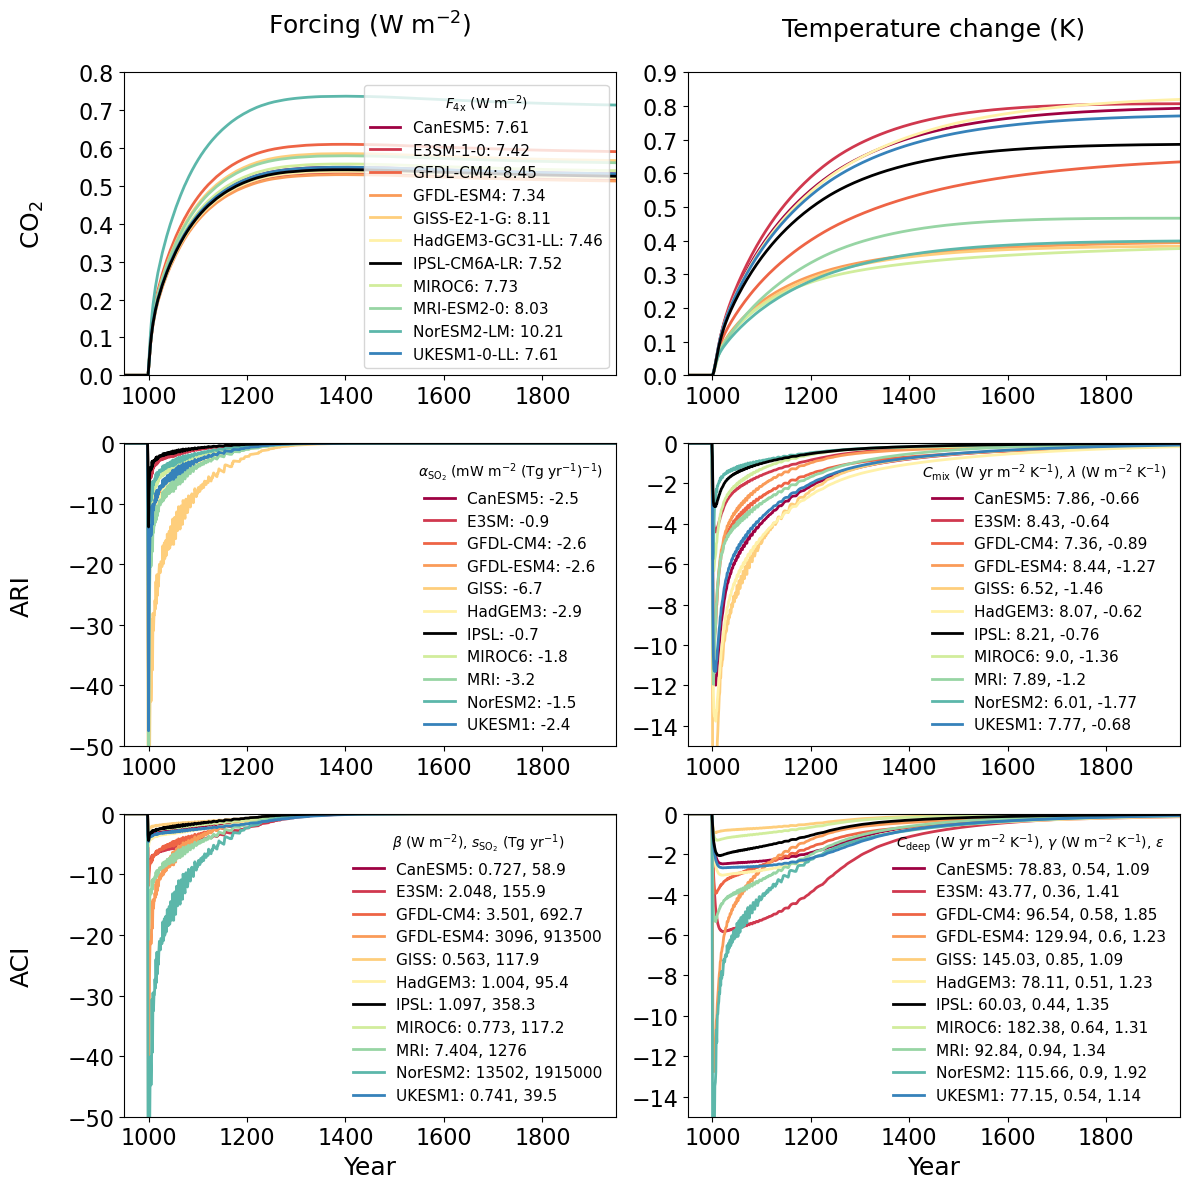

In [38]:
#
###Figure 8: Sensitivity to different model choice
#

plt.figure(figsize=(12,12))
plt.clf()

fs = 18

#CO2 forcing
plt.subplot(3,2,1)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 2
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['F']['GHG'][model],c=c,lw=2,zorder=zo,label=r'%s: %s' % (model,F_4x[model]))
plt.xlim(950,1950)
plt.ylim(0,0.8)
plt.legend(fontsize=fs-7,frameon=True,title=r'$F_\mathrm{4x}$ (W m$^{-2}$)',loc=4)

plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.title('Forcing (W %s)\n' % r'm$^{-2}$',fontsize=fs)
plt.ylabel('%s\n' % r'CO$_2$',fontsize=fs)

#CO2 temperature change
plt.subplot(3,2,2)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 10
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['Tmix']['GHG'][model],c=c,label=short_model[model],lw=2,zorder=zo)
plt.xlim(950,1950)
plt.ylim(0,0.9)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.title('Temperature change (K)\n',fontsize=fs)

#ARI forcing
plt.subplot(3,2,3)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 2
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['F']['ARI'][model],c=c,label=r'%s: %s' % (short_model[model],alpha_SO2[model]),lw=2,zorder=zo)
plt.xlim(950,1950)
plt.ylim(-50,0)
plt.legend(fontsize=fs-7,frameon=False,title=r'$\alpha_\mathrm{SO_2}$ (mW m$^{-2}$ (Tg yr$^{-1}$)$^{-1}$)',loc=4)
plt.ylabel('ARI\n',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)

#ARI temperature change
plt.subplot(3,2,4)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 10
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['Tmix']['ARI'][model],c=c,lw=2,zorder=zo,
             label=r'%s: %s, %s' % (short_model[model],C_mix[model],lmda[model]))
plt.legend(fontsize=fs-7,frameon=False,
    title=r'$C_\mathrm{mix}$ (W yr m$^{-2}$ K$^{-1}$), $\lambda$ (W m$^{-2}$ K$^{-1}$)',loc=4)
plt.xlim(950,1950)
plt.ylim(-15,0)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)

#ACI forcing
plt.subplot(3,2,5)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 10
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['F']['ACI'][model],c=c,lw=2,zorder=zo,label=r'%s: %s, %s' % (short_model[model],beta[model],s_SO2[model]))
plt.xlim(950,1950)
plt.ylim(-50,0)
plt.legend(fontsize=fs-7,frameon=False,title=r'$\beta$ (W m$^{-2}$), $s_\mathrm{SO_2}$ (Tg yr$^{-1}$)',loc=4)
plt.ylabel('ACI\n',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.xlabel('Year',fontsize=fs)

#ACI temperature change
plt.subplot(3,2,6)
for model, i in zip(models,np.arange(len(models))):
    if 'IPSL' in model: 
        c = 'k'
        zo = 10
    else: 
        c = cm.Spectral(i/len(models))
        zo = 1
    plt.plot(dd['Tmix']['ACI'][model],c=c,lw=2,zorder=zo,
             label=r'%s: %s, %s, %s' % (short_model[model],C_deep[model],gmma[model],epsn[model]))
plt.xlim(950,1950)
plt.ylim(-15,0)
plt.legend(fontsize=fs-7,frameon=False,
    title=r'$C_\mathrm{deep}$ (W yr m$^{-2}$ K$^{-1}$), $\gamma$ (W m$^{-2}$ K$^{-1}$), $\epsilon$',loc=4)
plt.yticks(fontsize=fs-2)
plt.xticks(fontsize=fs-2)
plt.xlabel('Year',fontsize=fs)

plt.tight_layout()

if defaults: plt.savefig(f'Fig8.pdf')

plt.show()

Figure 9: Sensitivity to emplacement duration
==

In [39]:
#
###10yr emissions
#

model = 'IPSL-CM6A-LR'

#SO2 emissions file in kg S yr-1
filename_S = f'10yr_Sflux_{mS}.csv'
E_SO2 = np.array(pd.read_csv(filename_S,header=None)).flatten() * (32+2*16)/32 * 1e-9 #Tg SO2 yr-1

#CO2 emissions in kg yr-1
filename_C = f'10yr_Cflux_{mC}.csv'
E_CO2 = np.array(pd.read_csv(filename_C,header=None)).flatten() * (12+2*16)/12 * 1e-9 #Tg CO2 yr-1
E_pCO2 = (E_CO2*1e9)/(4*np.pi*(6.3781*1e6)**2)*9.8*10 #µatm

#
###Recaclulate pCO2_atm
#

#Set integration parameters
dt = 1 #yr
Tr = 0.05 #yr-1
zeta = 1/250 #yr-1
pCO2_0 = 1500*(44/29)

#Initial values: Equilibrated with atmosphere at 1500 ppmv
pCO2_atm = [pCO2_0] #µatm
pCO2_mix = [pCO2_0] #µatm
pCO2_deep = [pCO2_0] #µatm
    
for i in range(1,len(E_CO2)): #Euler method
    dpCO2_atm = (E_pCO2[i-1]-Tr*(pCO2_atm[i-1]-pCO2_mix[i-1]))*dt
    dpCO2_mix = (Tr*(pCO2_atm[i-1]-pCO2_mix[i-1])-zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
    dpCO2_deep = (zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
        
    pCO2_atm.append(pCO2_atm[i-1]+dpCO2_atm)
    pCO2_mix.append(pCO2_mix[i-1]+dpCO2_mix)
    pCO2_deep.append(pCO2_deep[i-1]+dpCO2_deep)
        
pCO2_atm = np.array(pCO2_atm)
pCO2_mix = np.array(pCO2_mix)
pCO2_deep = np.array(pCO2_deep)

#Store temperature and forcing data

dd10 = {}
dd10['Tmix'] = {forcer : {} for forcer in forcers}
dd10['Tdeep'] = {forcer : {} for forcer in forcers}
dd10['F'] = {forcer : {} for forcer in forcers}

#Calculate temperature for each model
for model in [model]:
    for forcer in forcers:

        #Set forcing
        if forcer == 'ACI': F = ERFaci(model)
        elif forcer == 'ARI': F = ERFari(model)
        elif forcer == 'GHG': F = ERF_CO2(model)
        elif forcer == 'ALL': F = ERFaci(model)+ERFari(model)+ERF_CO2(model)
        elif forcer == 'GHG+ACI': F = ERFaci(model)+ERF_CO2(model)
        elif forcer == 'AER': F = ERFaci(model)+ERFari(model)

        #Initialize model
        Tmix = [0] #K
        Tdeep = [0] #K
        dt = 1 #yr

        for i in range(1,len(E_SO2)): #Euler method
            dTmix = (F[i-1] + lmda[model]*Tmix[i-1] - epsn[model]*gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_mix[model]
            dTdeep = (gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_deep[model]
            Tmix.append(Tmix[i-1]+dTmix)
            Tdeep.append(Tdeep[i-1]+dTdeep)    

        dd10['Tmix'][forcer][model] = np.array(Tmix)
        dd10['Tdeep'][forcer][model] = np.array(Tdeep)
        dd10['F'][forcer][model] = np.array(F)

In [40]:
#
###Volcanic-like emissions
#

model = 'IPSL-CM6A-LR'

#SO2 emissions file in kg S yr-1
filename_S = f'Instantaneous_Sflux_HF_volceq.csv'
E_SO2 = np.array(pd.read_csv(filename_S,header=None)).flatten() * (32+2*16)/32 * 1e-9 #Tg SO2 yr-1

#CO2 emissions in kg yr-1
filename_C = f'Instantaneous_Cflux_AR_volceq.csv'
E_CO2 = np.array(pd.read_csv(filename_C,header=None)).flatten() * (12+2*16)/12 * 1e-9 #Tg CO2 yr-1
E_pCO2 = (E_CO2*1e9)/(4*np.pi*(6.3781*1e6)**2)*9.8*10 #µatm

#
###Recaclulate pCO2_atm
#

#Set integration parameters
dt = 1 #yr
Tr = 0.05 #yr-1
zeta = 1/250 #yr-1
pCO2_0 = 1500*(44/29)

#Initial values: Equilibrated with atmosphere at 1500 ppmv
pCO2_atm = [pCO2_0] #µatm
pCO2_mix = [pCO2_0] #µatm
pCO2_deep = [pCO2_0] #µatm
    
for i in range(1,len(E_CO2)): #Euler method
    dpCO2_atm = (E_pCO2[i-1]-Tr*(pCO2_atm[i-1]-pCO2_mix[i-1]))*dt
    dpCO2_mix = (Tr*(pCO2_atm[i-1]-pCO2_mix[i-1])-zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
    dpCO2_deep = (zeta*(pCO2_mix[i-1]-pCO2_deep[i-1]))*dt
        
    pCO2_atm.append(pCO2_atm[i-1]+dpCO2_atm)
    pCO2_mix.append(pCO2_mix[i-1]+dpCO2_mix)
    pCO2_deep.append(pCO2_deep[i-1]+dpCO2_deep)
        
pCO2_atm = np.array(pCO2_atm)
pCO2_mix = np.array(pCO2_mix)
pCO2_deep = np.array(pCO2_deep)

#Store temperature and forcing data

ddV = {}
ddV['Tmix'] = {forcer : {} for forcer in forcers}
ddV['Tdeep'] = {forcer : {} for forcer in forcers}
ddV['F'] = {forcer : {} for forcer in forcers}

#Calculate temperature for each model
for model in [model]:
    for forcer in forcers:

        #Set forcing
        if forcer == 'ACI': F = ERFaci(model)
        elif forcer == 'ARI': F = ERFari(model)
        elif forcer == 'GHG': F = ERF_CO2(model)
        elif forcer == 'ALL': F = ERFaci(model)+ERFari(model)+ERF_CO2(model)
        elif forcer == 'GHG+ACI': F = ERFaci(model)+ERF_CO2(model)
        elif forcer == 'AER': F = ERFaci(model)+ERFari(model)

        #Initialize model
        Tmix = [0] #K
        Tdeep = [0] #K
        dt = 1 #yr

        for i in range(1,len(E_SO2)): #Euler method
            dTmix = (F[i-1] + lmda[model]*Tmix[i-1] - epsn[model]*gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_mix[model]
            dTdeep = (gmma[model]*(Tmix[i-1]-Tdeep[i-1])*dt)/C_deep[model]
            Tmix.append(Tmix[i-1]+dTmix)
            Tdeep.append(Tdeep[i-1]+dTdeep)    

        ddV['Tmix'][forcer][model] = np.array(Tmix)
        ddV['Tdeep'][forcer][model] = np.array(Tdeep)
        ddV['F'][forcer][model] = np.array(F)

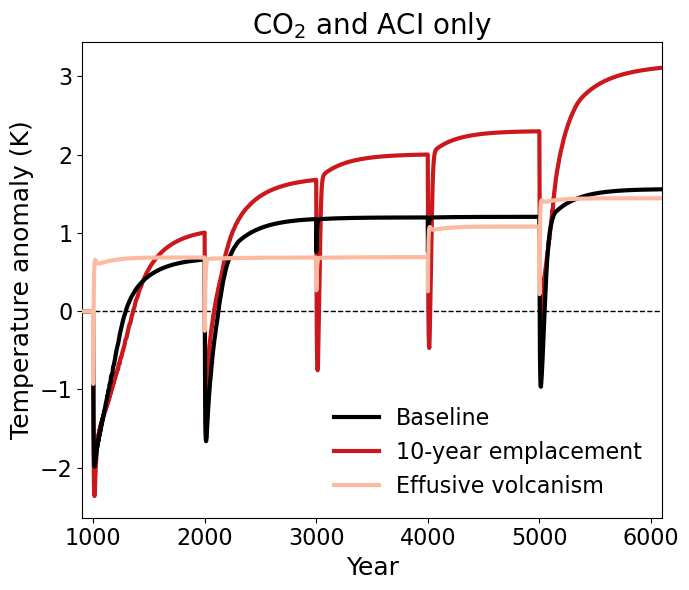

In [41]:
#
###Figure 9: Sensitivity to 10-yr emplacement or volcanic-like emissions
#

plt.figure(figsize=(7,6))
plt.clf()
fs = 18

plt.plot(dd['Tmix']['GHG+ACI']['IPSL-CM6A-LR'],label='Baseline',lw=3,c='k',zorder=6)
plt.plot(dd10['Tmix']['GHG+ACI']['IPSL-CM6A-LR'],label='10-year emplacement',lw=3,c=cm.Reds(.75),zorder=5)
plt.plot(ddV['Tmix']['GHG+ACI']['IPSL-CM6A-LR'],label='Effusive volcanism',lw=3,c=cm.Reds(.25),zorder=7)
plt.plot([0,8000],[0,0],'k--',lw=1)

plt.legend(frameon=False,fontsize=fs-2)
plt.ylabel(r'Temperature anomaly (K)',fontsize=fs)
plt.yticks(fontsize=fs-2)
plt.xlabel('Year',fontsize=fs)
plt.xticks(fontsize=fs-2)
plt.xlim(900,6100)

plt.title(r'CO$_2$ and ACI only',fontsize=fs+2)

plt.tight_layout()

if defaults: plt.savefig(f'Fig9.pdf')

plt.show()

References
==

Foster, G. L., Royer, D. L., & Lunt, D. J. (2017). Future climate forcing potentially without precedent in the last 420 million years. Nat Commun, 8, 14845. doi:10.1038/ncomms14845

Held, I. M., Winton, M., Takahashi, K., Delworth, T., Zeng, F., & Vallis, G. K. (2010). Probing the Fast and Slow Components of Global Warming by Returning Abruptly to Preindustrial Forcing. Journal of Climate, 23(9), 2418-2427. doi:10.1175/2009jcli3466.1

Smith, C. J., Harris, G. R., Palmer, M. D., Bellouin, N., Collins, W., Myhre, G., . . . Forster, P. M. (2021). Energy Budget Constraints on the Time History of Aerosol Forcing and Climate Sensitivity. Journal of Geophysical Research: Atmospheres, 126(13). doi:10.1029/2020jd033622


Takahashi, T., Sutherland, S. C., Wanninkhof, R., Sweeney, C., Feely, R. A., Chipman, D. W., . . . de Baar, H. J. W. (2009). Climatological mean and decadal change in surface ocean pCO2, and net sea–air CO2 flux over the global oceans. Deep Sea Research Part II: Topical Studies in Oceanography, 56(8-10), 554-577. doi:10.1016/j.dsr2.2008.12.009